# Задача

$$f(x) = \frac{p}{2} ||Ax - b||^2 + \sum_{i=1}^m \log ( 2 \cosh (u_i^\top (x - a))),$$

$$a \in \R^n, b \in \R^m, A \in \R^{m \times n}, u_i \in \R^n, p \ge 0, m=\frac{n}{5}.$$


In [ ]:
import time
import numpy as np
import cvxpy as cp

from tqdm import tqdm
from prettytable import PrettyTable
import matplotlib.pyplot as plt

In [30]:
def generate_problem(n, rng = None):

    if rng is None:
        rng = np.random

    m = max(1, n // 5)

    A = np.random.randn(m, n)
    b = np.random.randn(m)
    a = np.random.randn(n)
    U = np.random.randn(m, n)
    p = np.random.rand() + 0.1   # always should be > 0

    return A, b, a, U, p

### Найдем эталонное решение через CVXPY solver
Это допустимо так как функция выпуклая и локальный минимум равен глобальному минимуму.

CVXPY решает задачу

$x^* = argmin_x f(x)$

и возвращает точку $x*$ \
которая удовлетворяет:

$\nabla f(x^∗) \approx 0$

В *CVXPY* функция $cosh$ не поддерживается. Поэтому необходимо ее преобразовать.

По определению: \
$cosh(z) = \frac{e^z + e^{-z}}{2}$

Тогда: \
$log(2 \cdot cosh(z)) = log(2 \cdot \frac{e^z + e^{-z}}{2}​) = log(e^z + e^{−z})$

Получим \
$log(2 \cdot cosh(z))$ эквивалентно $log(e^z + e^{−z})$

In [3]:
def solve_with_cvxpy(A, b, a, U, p):
    n = A.shape[1]
    x = cp.Variable(n)

    term1 = (p/2) * cp.sum_squares(A @ x - b)
    z = U @ (x - a)
    term2 = cp.sum(
        cp.log_sum_exp(cp.vstack([z, -z]), axis=0)
    )

    objective = cp.Minimize(term1 + term2)
    problem = cp.Problem(objective)
    problem.solve(solver=cp.SCS, verbose=False)

    if problem.status != cp.OPTIMAL:
        return None

    return x.value

### Реализуем градиент

$\nabla f(x)=p \cdot A^⊤(Ax−b) + U^⊤ \cdot tanh(U(x−a))$

In [4]:
def gradient(x, A, b, a, U, p):
    g1 = p * A.T @ (A @ x - b)
    z = U @ (x - a)
    g2 = U.T @ np.tanh(z)

    return g1 + g2

### Проверка условия оптимальности

Условие:

$\nabla f(x^∗)=0$

Численно проверяем:

$||\nabla f(x^∗)|| < 10 − 6$

In [5]:
def check_optimality(x_star, A, b, a, U, p):
    g = gradient(x_star, A, b, a, U, p)

    return np.linalg.norm(g)

### Генерируем 100 задач для каждого $n$

Основной цикл эксперимента

In [6]:
solver_results = {}
problems = {n: [] for n in range(10,101,10)}

for n in tqdm(range(10, 101, 10), desc="Solving task"):

    grad_norms = []

    for _ in range(100):

        A, b, a, U, p = generate_problem(n)

        x_star = solve_with_cvxpy(A, b, a, U, p)

        if x_star is None:
            print("Solver не сошелся")
            continue

        problems[n].append({
            "A": A,
            "b": b,
            "a": a,
            "U": U,
            "p": p,
            "x_star": x_star
        })

        grad_norm = check_optimality(x_star, A, b, a, U, p)
        grad_norms.append(grad_norm)

    solver_results[n] = grad_norms

Solving task: 100%|██████████| 10/10 [00:05<00:00,  1.76it/s]


In [7]:
print("\nExample problems: \nValues and their shapes in the first problem:")
for k, v in problems[10][0].items():
    print(f"{k}: {v.shape if not isinstance(v, float) else v}")


Example problems: 
Values and their shapes in the first problem:
A: (2, 10)
b: (2,)
a: (10,)
U: (2, 10)
p: 0.5618393241711411
x_star: (10,)


`x_star` - это оптимальное решение: \
$x^∗ = argmin(f(x))$

In [8]:
from pprint import pp
for i in range (5):
    print(f"\nBest result for task {i}")
    pp(problems[10][i]["x_star"])


Best result for task 0
array([ 0.0066972 , -0.26107978,  0.1355903 , -0.29366208, -0.30510077,
       -0.16753472, -0.13720081, -0.07511776,  0.14505899, -0.64633005])

Best result for task 1
array([-1.2972509 ,  1.18730002,  0.78624893,  0.66645606,  0.40465616,
       -0.98396677,  0.66419769, -1.22768349,  1.19570747, -1.18080867])

Best result for task 2
array([ 0.44411141, -0.46646876, -0.29450069,  0.14023964, -0.9970663 ,
        0.164575  ,  0.23615049, -0.31256186,  0.20061372, -0.91713448])

Best result for task 3
array([-0.27714837, -0.13511584, -0.26222697,  0.54361416, -0.18127447,
       -0.32778372,  0.00557123,  0.35953129, -0.3277401 ,  0.11016139])

Best result for task 4
array([-0.11556473,  0.28261554,  0.17541798, -0.10154753, -0.32160262,
        0.24729566,  0.3295435 , -0.42790204,  0.44115335,  1.05442295])


In [9]:
print(f"{len(solver_results)} results were computed")
print(f"{len(solver_results[10])} gradient norms in each result")

10 results were computed
100 gradient norms in each result


## Linear Coupling

из работы *Zeyuan Allen-Zhu и Lorenzo Orecchia.*

Главная идея: \
Ускоренный метод представленный как комбинация двух методов
1. gradient descent
2. mirror descent

Эта комбинация называется **coupling** (связывание).

`Градиентный спуск` делает шаг в пространстве переменных: \
$x_{k+1}​ = x_k ​− \eta \cdot \nabla f(x_k​)$ \
где $x_k$ - текущая точка, $\eta$ - шаг.

Простыми словвами мы смотрим **наклон функции** и двигаемся в противоположную сторону. \
При этом шаг делается в евклидовом пространстве напрямую.

`Mirror descent` делает шаг не в пространстве $x$, а сначала в дуальном пространстве. \
Алгоритм состоит из двух шагов:
1. Шаг в dual space \
    $z_{k+1} ​= z_k ​− \eta \nabla f(x_k​)$
2. Возвращение в пространство $x$ \
    $x_{k+1} ​= \nabla \varphi \cdot (z_k + 1​)$, \
    где $\varphi$ - специальная функция (mirror map)

Иначе говоря `mirror descent` делает:
1. преобразование координат
2. градиентный шаг
3. обратное преобразование

В евклидовом случае, если взять \
$\phi(x) = \frac{1}{2}||x||^2$ \
то `mirror descent` совпадает с `gradient descent`. \
Поэтому `gradient descent` — частный случай `mirror descent`.

`Linear coupling` поддерживает две точки:
1. $x_k$ - точка gradient descent
2. $z_k$ - точка mirror descent

Сначала они смешиваются: \
$y_k ​= (1 − \tau) \cdot x_k ​+ \tau \cdot z_k$

Из точки $y_k$ делаем обычный шаг градиентного спуска: \
$x_{k+1} ​= y_k ​− \frac{1}{L}​ \cdot \nabla f(y_k​)$

Затем обновляется $z_k$, делается шаг mirror descend: \
$z_{k+1} ​= z_k ​− \alpha \cdot \nabla f(y_k​)$

`Linear coupling` математически эквивалентен ускоренному методу Нестерова.

То есть \
$y_k ​= (1−\tau) \cdot x_k ​+ \tau \cdot z_k$ \
играет роль momentum шага, что создаёт ускоренное движение к минимуму.

#### Обозначим саму задачу для линейного каплинга

In [10]:
def f_value(x, A, b, a, U, p):
    term1 = (p/2) * np.linalg.norm(A @ x - b)**2
    z = U @ (x - a)
    term2 = np.sum(np.log(2*np.cosh(z)))
    return term1 + term2

Оценка $L$

In [12]:
def estimate_L(A, U, p):
    LA = np.linalg.norm(A, 2)**2
    LU = np.linalg.norm(U, 2)**2
    return p * LA + LU

Стандартный линейный каплинг

Для выпуклого случая \
$\tau = \frac{2}{k+2}$

In [13]:
def linear_coupling(x0, A, b, a, U, p, eps=1e-2, max_iter=10000):
    x = x0.copy()
    z = x0.copy()

    L = estimate_L(A, U, p)
    history = [x.copy()]

    for k in range(1, max_iter):
        tau = 2/(k+2)
        y = (1-tau)*x + tau*z  # mixing
        g = gradient(y, A, b, a, U, p)

        x_new = y - (1/L)*g  # gradient step
        z_new = z - (1/(tau*L))*g  # mirror step

        history.append(x_new.copy())

        if np.linalg.norm(g) < eps:
            return x_new, k, history

        x = x_new
        z = z_new

    return x, max_iter, history

#### Линейный каплинг с restart

Restart делается просто: \
если momentum начинает вредить, сбрасываем состояние.

$(x_{k+1} ​− x_k​)^{\top} \cdot (x_k ​− x_{k−1}​) > 0$

In [14]:
def linear_coupling_restart(x0, A, b, a, U, p, eps=1e-2, max_iter=10000):
    x = x0.copy()
    z = x0.copy()

    L = estimate_L(A, U, p)
    history = [x.copy()]
    x_prev = x.copy()

    for k in range(1, max_iter):
        tau = 2/(k+2)

        y = (1-tau)*x + tau*z
        g = gradient(y, A, b, a, U, p)

        x_new = y - (1/L)*g
        z_new = z - (1/(tau*L))*g

        if np.dot(x_new-x, x-x_prev) > 0:
            z_new = x_new.copy()

        history.append(x_new.copy())

        if np.linalg.norm(g) < eps:
            return x_new, k, history

        x_prev = x
        x = x_new
        z = z_new

    return x, max_iter, history

#### Линейный каплинг с momentum

**Метод Нестерова**: \
Использует две последовательности $x_k$ и $y_k$
1. Градиентный шаг \
    $x_{k+1} ​= y_k ​− \frac{1}{L} \cdot ​\nabla f(y_k​)$
2. Momentum \
    $y_{k+1} ​= x_{k+1}​ + \beta_k \cdot ​(x_{k+1} ​− x_k​)$, где \
    $\beta_k = \frac{k-1}{k+2}$

Этот член \
$x_{k+1} - x_k$ \
уже выполняет ту же роль, что и «ускорение» в linear coupling. \
Метод движется не просто по градиенту, а продолжает предыдущий шаг.

Ранее мы выяснили что оценка $\mu = 0$. \
$\beta_k = \frac{k - 1}{k + 1}$

Это может говорить о том, что функция не имеет сильной выпуклости. \

Когда $\mu > 0$ \
Скорость становится \
$f(x_k​) − f(x^∗) = O(exp(−k\sqrt{\frac{\mu}{L}}​))$ \
Но тогда моментум должен зависеть от $\mu$ \
$\beta = \frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$

А рестарты как раз используются, когда алгоритм рассчитан на общую выпуклость, а задача на самом деле сильно выпуклая.

Если при $\mu = 0$ использовать рестарты, то периодически моментум будет обнуляться, теряя накопленное ускорение. \
Поэтому метод становится медленнее, ближе к обычному градиентному спуску.

В нашем случае выпуклость стандатная, поэтому лучшей возможной скорости уже достигает обычный momentum. \
**Рестарты не нужны**


In [25]:
A, b, a, U, p = generate_problem(50)

ATA = A.T @ A

rank_A = np.linalg.matrix_rank(A)
eigvals = np.linalg.eigvalsh(ATA)

print("matrix A shape:", A.shape)
print("rank(A):", rank_A)
print("n:", A.shape[1])
print("min eigenvalue:", eigvals[0])
print("max eigenvalue:", eigvals[-1])

zero_eigs = np.sum(eigvals < 1e-10)
print("zero eigenvalues:", zero_eigs)

matrix A shape: (10, 50)
rank(A): 10
n: 50
min eigenvalue: -3.151587566478306e-14
max eigenvalue: 86.90846863727339
zero eigenvalues: 40


In [15]:
def nesterov_method(x0, A, b, a, U, p, eps=1e-2, max_iter=10000):

    x = x0.copy()
    y = x0.copy()

    L = estimate_L(A, U, p)
    history = [x.copy()]

    for k in range(1, max_iter):
        g = gradient(y, A, b, a, U, p)

        x_new = y - (1/L)*g
        beta = (k-1)/(k+2)
        y = x_new + beta*(x_new-x)

        history.append(x_new.copy())

        if np.linalg.norm(g) < eps:
            return x_new, k, history

        x = x_new

    return x, max_iter, history

In [16]:
def generate_start_points(n, num_points=100):
    return [np.random.randn(n) for _ in range(num_points)]

### График траектории метода linear coupling with momentum

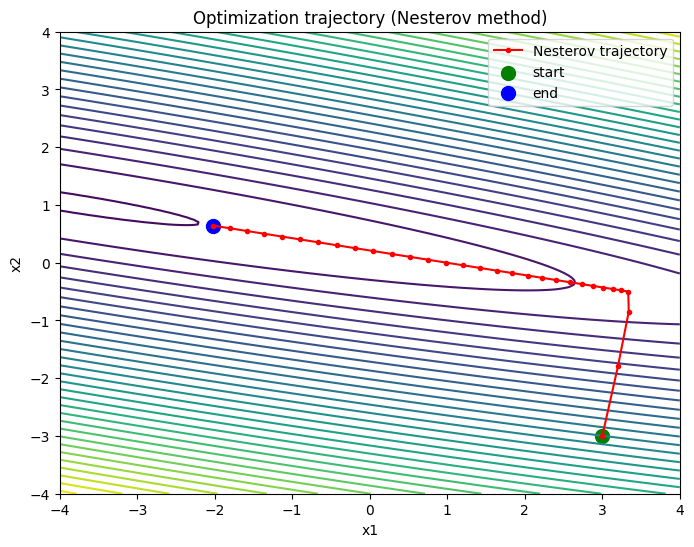

In [ ]:
n = 2
A, b, a, U, p = generate_problem(n)
x0 = np.array([3.0, -3.0])

x_star, iters, history = nesterov_method(x0, A, b, a, U, p)
history = np.array(history)

x1 = np.linspace(-4, 4, 200)
x2 = np.linspace(-4, 4, 200)

X1, X2 = np.meshgrid(x1, x2)
Z = np.zeros_like(X1)

for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x = np.array([X1[i, j], X2[i, j]])
        Z[i, j] = f_value(x, A, b, a, U, p)

plt.figure(figsize=(8,6))
plt.contour(X1, X2, Z, levels=30)
plt.plot(history[:,0], history[:,1], 'r-o', markersize=3, label="Nesterov trajectory")

plt.scatter(history[0,0], history[0,1], c='green', s=100, label="start")
plt.scatter(history[-1,0], history[-1,1], c='blue', s=100, label="end")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Optimization trajectory (Nesterov method)")
plt.legend()
plt.show()

В 2-мерном случае получается:
- одно направление очень крутое ($x2$)
- другое почти плоское ($x1$)

Несколько первых шагов алгоритм быстро корректирует координату x2, так как градиент всегда направлен в сторону наибольшего роста функции.

Когда x2 становится почти оптимальным остаётся градиент по x1 поэтому траектория поворачивает и начинает двигаться вдоль x1


### Сравнение времени работы и количества итераций

In [17]:
def run_experiment(algorithm, problems, eps=1e-2, n_starts=100):
    results = {}
    for n in tqdm(problems, desc=f"Solving with {algorithm.__name__}"):
        times = []
        iterations = []
        for problem in problems[n]:

            A = problem["A"]
            b = problem["b"]
            a = problem["a"]
            U = problem["U"]
            p = problem["p"]

            for _ in range(n_starts):
                x0 = np.random.randn(n)
                start = time.time()

                _, iters, _ = algorithm(
                    x0, A, b, a, U, p, eps
                )
                elapsed = time.time() - start
                times.append(elapsed)
                iterations.append(iters)

        results[n] = {
            "avg_time": np.mean(times),
            "avg_iters": np.mean(iterations)
        }

    return results

In [18]:
lc_results = run_experiment(linear_coupling, problems)

Solving with linear_coupling: 100%|██████████| 10/10 [01:48<00:00, 10.88s/it]


In [19]:
lc_restart_results = run_experiment(linear_coupling_restart, problems)

Solving with linear_coupling_restart: 100%|██████████| 10/10 [03:29<00:00, 20.90s/it]


In [20]:
nesterov_results = run_experiment(nesterov_method, problems)

Solving with nesterov_method: 100%|██████████| 10/10 [01:37<00:00,  9.71s/it]


In [ ]:
def print_results_table(n, lc_results, lc_restart_results, nesterov_results):
    table = PrettyTable()
    table.title = f"Results for n = {n}"

    table.field_names = [
        "Method",
        "Avg Time (s)",
        "Avg Iterations"
    ]

    table.add_row([
        "Linear Coupling",
        f"{lc_results[n]['avg_time']:.6f}",
        f"{lc_results[n]['avg_iters']:.2f}"
    ])

    table.add_row([
        "LC + Restart",
        f"{lc_restart_results[n]['avg_time']:.6f}",
        f"{lc_restart_results[n]['avg_iters']:.2f}"
    ])

    table.add_row([
        "Nesterov (Momentum)",
        f"{nesterov_results[n]['avg_time']:.6f}",
        f"{nesterov_results[n]['avg_iters']:.2f}"
    ])

    print(table)

In [22]:
for n in range(10,101,10):
    print_results_table(n, lc_results, lc_restart_results, nesterov_results)

+-----------------------------------------------------+
|                  Results for n = 10                 |
+---------------------+--------------+----------------+
|        Method       | Avg Time (s) | Avg Iterations |
+---------------------+--------------+----------------+
|   Linear Coupling   |   0.000272   |     33.12      |
|     LC + Restart    |   0.000802   |     77.85      |
| Nesterov (Momentum) |   0.000239   |     33.13      |
+---------------------+--------------+----------------+
+-----------------------------------------------------+
|                  Results for n = 20                 |
+---------------------+--------------+----------------+
|        Method       | Avg Time (s) | Avg Iterations |
+---------------------+--------------+----------------+
|   Linear Coupling   |   0.000515   |     64.36      |
|     LC + Restart    |   0.001130   |     129.04     |
| Nesterov (Momentum) |   0.000442   |     64.45      |
+---------------------+--------------+----------

По результатам экспериментов видно, что методы `Linear Coupling` и `Nesterov (Momentum)` демонстрируют практически одинаковое поведение: среднее число итераций и время работы у них почти совпадают для всех значений n. \
Это подтверждает теоретический факт, что метод Нестерова является одной из форм реализации линейного каплинга и имеет ту же скорость сходимости.

Метод `Linear Coupling с рестартами` показывает значительно худшие результаты: он требует примерно в 1.5–2 раза больше итераций и соответственно больше времени. \
Это может объясняться тем, что в рассматриваемой задаче параметр сильной выпуклости $\mu=0$, поэтому рестарты не дают преимущества и фактически приводят к потере накопленного ускорения.

Также видно, что с ростом размерности n увеличиваются как время работы, так и число итераций для всех методов. Однако рост происходит достаточно плавно, а относительное соотношение между методами сохраняется: наиболее эффективными остаются `Linear Coupling` и `Nesterov`, тогда как вариант с рестартами стабильно работает медленнее.

### Зависимость точности от числа итераций для стандартного линейного каплинга

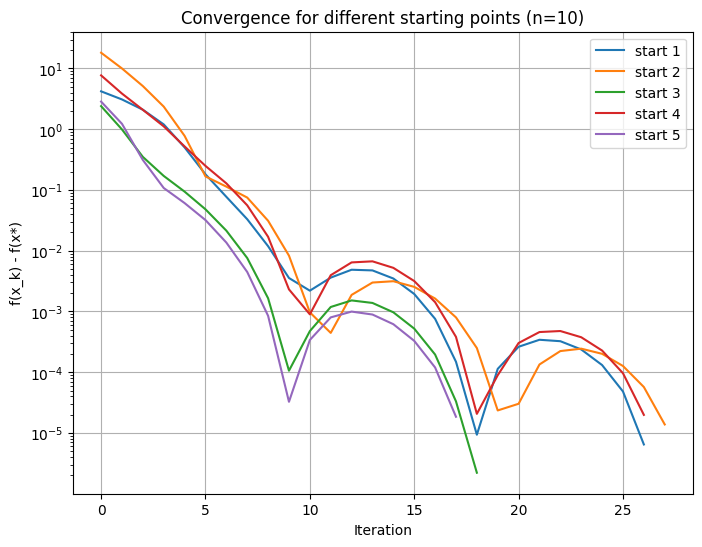

In [35]:
problem = problems[10][0]

A = problem["A"]
b = problem["b"]
a = problem["a"]
U = problem["U"]
p = problem["p"]
x_star = problem["x_star"]

f_star = f_value(x_star, A, b, a, U, p)

n_starts = 5
max_iter = 500

plt.figure(figsize=(8,6))

for i in range(n_starts):

    x0 = np.random.randn(10)

    x_opt, iters, history = linear_coupling(
        x0, A, b, a, U, p, eps=1e-2, max_iter=max_iter
    )

    errors = []

    for x in history:
        f = f_value(x, A, b, a, U, p)
        errors.append(f - f_star)

    plt.plot(errors, label=f"start {i+1}")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("f(x_k) - f(x*)")
plt.title("Convergence for different starting points (n=10)")
plt.legend()
plt.grid()
plt.show()

Зависимость $f(x_k) - f(x^*)$ от числа итераций убывает для всех начальных точек, что подтверждает сходимость метода. \
Различие начальных значений связано с выбором стартовой точки, однако скорость уменьшения ошибки остаётся схожей.

### Зависимость скорости сходмости от отношения $\frac{\mu}{L}$

Скорость сходимости ускоренных методов зависит от отношения $\frac{\mu}{L}$. При $\mu > 0$ методы имеют линейную (экспоненциальную) скорость сходимости \
$O(exp(-k\sqrt{\frac{\mu}{L}}))$, причём увеличение $\frac{\mu}{L}$ ускоряет сходимость. \
В рассматриваемой задаче $\mu = 0$, поэтому наблюдается лишь субквадратичная скорость $O(\frac{1}{k^2})$.

In [36]:
def estimate_mu(x, A, a, U, p):
    z = U @ (x - a)

    D = 1 - np.tanh(z)**2
    H = p * A.T @ A + U.T @ (D[:, None] * U)

    eigvals = np.linalg.eigvalsh(H)
    return np.min(eigvals)

In [37]:
mu = estimate_mu(x_star, A, a, U, p)
L = estimate_L(A, U, p)

print("mu =", mu)
print("L =", L)
print("mu/L =", mu/L)

mu = -1.6514148770756452e-15
L = 14.11596793700013
mu/L = -1.1698913488936397e-16


### Адаптивный подбор шага

вместо использования глобальной оценки L алгоритм сам подбирает локальную гладкость функции.

In [38]:
def backtracking(y, g, A, b, a, U, p, L_init=1.0, eta=2.0):
    L = L_init
    f_y = f_value(y, A, b, a, U, p)

    while True:
        x_new = y - (1/L) * g
        f_new = f_value(x_new, A, b, a, U, p)

        rhs = f_y + g @ (x_new - y) + (L/2) * np.linalg.norm(x_new - y)**2

        if f_new <= rhs:
            break

        L *= eta

    return x_new, L

In [ ]:
def linear_coupling_adaptive(x0, A, b, a, U, p, eps=1e-2, max_iter=10000):
    x = x0.copy()
    z = x0.copy()

    L = 1.0
    history = [x.copy()]

    for k in range(1, max_iter):
        tau = 2/(k+2)
        y = (1-tau)*x + tau*z

        g = gradient(y, A, b, a, U, p)
        x_new, L = backtracking(y, g, A, b, a, U, p, L)
        z_new = z - (1/(tau*L))*g
        history.append(x_new.copy())

        if np.linalg.norm(g) < eps:
            return x_new, k, history

        x = x_new
        z = z_new

    return x, max_iter, history

In [ ]:
def linear_coupling_restart_adaptive(
        x0, A, b, a, U, p, eps=1e-2, max_iter=10000
    ):

    x = x0.copy()
    z = x0.copy()
    x_prev = x.copy()

    L = 1.0
    history = [x.copy()]

    for k in range(1, max_iter):
        tau = 2/(k+2)

        y = (1-tau)*x + tau*z
        g = gradient(y, A, b, a, U, p)

        x_new, L = backtracking(y, g, A, b, a, U, p, L)
        z_new = z - (1/(tau*L))*g

        if np.dot(x_new - x, x - x_prev) > 0:
            z_new = x_new.copy()

        history.append(x_new.copy())

        if np.linalg.norm(g) < eps:
            return x_new, k, history

        x_prev = x
        x = x_new
        z = z_new

    return x, max_iter, history

In [ ]:
def nesterov_adaptive(x0, A, b, a, U, p, eps=1e-2, max_iter=10000):
    x = x0.copy()
    y = x0.copy()

    L = 1.0
    history = [x.copy()]

    for k in range(1, max_iter):
        g = gradient(y, A, b, a, U, p)

        x_new, L = backtracking(y, g, A, b, a, U, p, L)
        beta = (k-1)/(k+2)
        y = x_new + beta*(x_new - x)

        history.append(x_new.copy())
        if np.linalg.norm(g) < eps:
            return x_new, k, history

        x = x_new

    return x, max_iter, history

In [44]:
results_adaptive = run_experiment(linear_coupling_adaptive, problems)
results_restarts_adaptive = run_experiment(linear_coupling_restart_adaptive, problems)
results_nesterov_adaptive = run_experiment(nesterov_adaptive, problems)

Solving with linear_coupling_adaptive:  40%|████      | 4/10 [00:46<01:19, 13.21s/it]/tmp/ipykernel_208621/1814693977.py:4: RuntimeWarning: overflow encountered in cosh
  term2 = np.sum(np.log(2*np.cosh(z)))
Solving with linear_coupling_adaptive:  50%|█████     | 5/10 [01:06<01:18, 15.66s/it]/tmp/ipykernel_208621/1814693977.py:4: RuntimeWarning: overflow encountered in multiply
  term2 = np.sum(np.log(2*np.cosh(z)))
Solving with nesterov_adaptive: 100%|██████████| 10/10 [03:09<00:00, 18.92s/it]


In [45]:
for n in range(10,101,10):
    print_results_table(n, results_adaptive, results_restarts_adaptive, results_nesterov_adaptive)

+-----------------------------------------------------+
|                  Results for n = 10                 |
+---------------------+--------------+----------------+
|        Method       | Avg Time (s) | Avg Iterations |
+---------------------+--------------+----------------+
|   Linear Coupling   |   0.000656   |     25.46      |
|     LC + Restart    |   0.001091   |     50.62      |
| Nesterov (Momentum) |   0.000646   |     25.09      |
+---------------------+--------------+----------------+
+-----------------------------------------------------+
|                  Results for n = 20                 |
+---------------------+--------------+----------------+
|        Method       | Avg Time (s) | Avg Iterations |
+---------------------+--------------+----------------+
|   Linear Coupling   |   0.000949   |     45.43      |
|     LC + Restart    |   0.001738   |     72.87      |
| Nesterov (Momentum) |   0.000871   |     44.79      |
+---------------------+--------------+----------

Методы Linear Coupling и Nesterov показывают практически одинаковую скорость сходимости, при этом Nesterov немного быстрее по времени. Добавление рестартов не улучшает сходимость и даже увеличивает число итераций, что объясняется отсутствием сильной выпуклости ($\mu=0$).